#  <p align="center"> *Full RFM Segmentation and Customer Profiling*

---

### Import Necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

### Loading a Dataset

In [2]:
pd.set_option('display.max_columns', None) # Display all columns in the DataFrame
df = pd.read_csv('sales_data_sample.csv', encoding = 'latin1') # Load the dataset
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


### Familiarizing with Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [4]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [5]:
df.size

70575

In [6]:
df.shape

(2823, 25)

In [7]:
df.isnull().sum() # Check for missing values in each column

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [9]:
df.duplicated().sum() # Check for duplicate rows

0

### Data Handling

In [10]:
df['ORDERDATE'] = df['ORDERDATE'].apply(pd.to_datetime) # Convert 'ORDERDATE' to datetime format

In [11]:
df.drop(columns=['ADDRESSLINE2', 'STATE', 'POSTALCODE', 'TERRITORY'], inplace=True) # Drop unnecessary columns

In [12]:
df.columns # Check column names in the DataFrame

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'CITY', 'COUNTRY', 'CONTACTLASTNAME',
       'CONTACTFIRSTNAME', 'DEALSIZE'],
      dtype='object')

### RFM Analysis

In [ ]:
from datetime import timedelta # Import timedelta for date calculations
reference_date = df['ORDERDATE'].max() + timedelta(days=1) # Set reference date to one day after the latest order date
reference_date

Timestamp('2005-06-01 00:00:00')

#### Calculation of Recency

In [15]:
Recency = (reference_date - df.groupby('CUSTOMERNAME')['ORDERDATE'].max()).reset_index(name='RECENCY') # Calculate recency for each customer
Recency = Recency.sort_values(ascending=False, by='RECENCY') # Sort customers by recency in descending order
Recency

,CUSTOMERNAME,RECENCY
49,"Men 'R' US Retailers, Ltd.",509 days
30,"Double Decker Gift Stores, Ltd",496 days
90,West Coast Collectables Co.,489 days
73,Signal Collectibles Ltd.,477 days
26,Daedalus Designs Imports,466 days
...,...,...
75,Souveniers And Things Co.,3 days
28,Diecast Classics Inc.,2 days
64,Petit Auto,2 days
33,Euro Shopping Channel,1 days


#### Calculation of Frequency

In [16]:
Frequency = df.groupby('CUSTOMERNAME')['ORDERNUMBER'].nunique().reset_index() # Calculate frequency for each customer by counting unique order numbers
Frequency.columns = ['CUSTOMERNAME', 'FREQUENCY'] # Rename columns for clarity
Frequency = Frequency.sort_values('FREQUENCY', ascending=False) # Sort customers by frequency in descending order
Frequency

,CUSTOMERNAME,FREQUENCY
33,Euro Shopping Channel,26
55,Mini Gifts Distributors Ltd.,17
6,"Australian Collectors, Co.",5
31,"Dragon Souveniers, Ltd.",5
27,Danish Wholesale Imports,5
...,...,...
30,"Double Decker Gift Stores, Ltd",2
62,Osaka Souveniers Co.,2
61,Online Mini Collectables,2
91,giftsbymail.co.uk,2


#### Calculation of Monetary

In [17]:
Monetary = df.groupby('CUSTOMERNAME')['SALES'].sum().reset_index() # Calculate monetary value for each customer by summing sales
Monetary.columns = ['CUSTOMERNAME', 'MONETARY'] # Rename columns for clarity
Monetary = Monetary.sort_values('MONETARY', ascending=False) # Sort customers by monetary value in descending order
Monetary 

,CUSTOMERNAME,MONETARY
33,Euro Shopping Channel,912294.11
55,Mini Gifts Distributors Ltd.,654858.06
6,"Australian Collectors, Co.",200995.41
58,Muscle Machine Inc,197736.94
44,La Rochelle Gifts,180124.90
...,...,...
69,Royale Belge,33440.10
50,Microscale Inc.,33144.93
10,Auto-Moto Classics Inc.,26479.26
4,Atelier graphique,24179.96


#### Quantile Based Segmentation 

In [ ]:
Recency['R_score'] = pd.qcut(Recency['RECENCY'], q=4, labels=['4', '3', '2', '1'])  # Assign RFM scores for recency using quartiles
Recency

,CUSTOMERNAME,RECENCY,R_score
49,"Men 'R' US Retailers, Ltd.",509 days,1
30,"Double Decker Gift Stores, Ltd",496 days,1
90,West Coast Collectables Co.,489 days,1
73,Signal Collectibles Ltd.,477 days,1
26,Daedalus Designs Imports,466 days,1
...,...,...,...
75,Souveniers And Things Co.,3 days,4
28,Diecast Classics Inc.,2 days,4
64,Petit Auto,2 days,4
33,Euro Shopping Channel,1 days,4


In [20]:
Frequency['F_score'] = pd.qcut(Frequency['FREQUENCY'].rank(method='first'), q=4, labels=['1', '2', '3', '4']) # Assign F scores based on frequency quartiles (4 = most frequent, 1 = least frequent)
Frequency

,CUSTOMERNAME,FREQUENCY,F_score
33,Euro Shopping Channel,26,4
55,Mini Gifts Distributors Ltd.,17,4
6,"Australian Collectors, Co.",5,4
31,"Dragon Souveniers, Ltd.",5,4
27,Danish Wholesale Imports,5,4
...,...,...,...
30,"Double Decker Gift Stores, Ltd",2,2
62,Osaka Souveniers Co.,2,2
61,Online Mini Collectables,2,2
91,giftsbymail.co.uk,2,2


In [21]:
Monetary['M_score'] = pd.qcut(Monetary['MONETARY'].rank(method='first'), q=4, labels=['1', '2', '3', '4']) # Assign M scores based on monetary quartiles (4 = highest spenders, 1 = lowest spenders)
Monetary

,CUSTOMERNAME,MONETARY,M_score
33,Euro Shopping Channel,912294.11,4
55,Mini Gifts Distributors Ltd.,654858.06,4
6,"Australian Collectors, Co.",200995.41,4
58,Muscle Machine Inc,197736.94,4
44,La Rochelle Gifts,180124.90,4
...,...,...,...
69,Royale Belge,33440.10,1
50,Microscale Inc.,33144.93,1
10,Auto-Moto Classics Inc.,26479.26,1
4,Atelier graphique,24179.96,1


---

#### RFM Segmentation

In [22]:
RFM_segment = pd.concat([Recency.set_index('CUSTOMERNAME')['R_score'], Frequency.set_index('CUSTOMERNAME')['F_score'], Monetary.set_index('CUSTOMERNAME')['M_score']], axis=1).reset_index() # Combine R, F, M scores into a single DataFrame
RFM_segment['RFM_Score'] = RFM_segment['R_score'].astype(str) + RFM_segment['F_score'].astype(str) + RFM_segment['M_score'].astype(str) # Create RFM score by concatenating R, F, M scores
RFM_segment

,CUSTOMERNAME,R_score,F_score,M_score,RFM_Score
0,"Men 'R' US Retailers, Ltd.",1,1,1,111
1,"Double Decker Gift Stores, Ltd",1,2,1,121
2,West Coast Collectables Co.,1,1,1,111
3,Signal Collectibles Ltd.,1,1,1,111
4,Daedalus Designs Imports,1,2,1,121
...,...,...,...,...,...
87,Souveniers And Things Co.,4,4,4,444
88,Diecast Classics Inc.,4,4,4,444
89,Petit Auto,4,2,2,422
90,Euro Shopping Channel,4,4,4,444


In [24]:
RFM_segment['RFM_Score'] = RFM_segment['RFM_Score'].astype(int) # Convert RFM_Score to integer type for better analysis 
RFM_segment['Segment_name'] = pd.qcut(RFM_segment['RFM_Score'], q=5, labels=['Lost', 'Needs Attention', 'At Risk', 'Loyal', 'Champions'])  # Create segment names based on RFM score quartiles
RFM_segment

,CUSTOMERNAME,R_score,F_score,M_score,RFM_Score,Segment_name
0,"Men 'R' US Retailers, Ltd.",1,1,1,111,Lost
1,"Double Decker Gift Stores, Ltd",1,2,1,121,Lost
2,West Coast Collectables Co.,1,1,1,111,Lost
3,Signal Collectibles Ltd.,1,1,1,111,Lost
4,Daedalus Designs Imports,1,2,1,121,Lost
...,...,...,...,...,...,...
87,Souveniers And Things Co.,4,4,4,444,Champions
88,Diecast Classics Inc.,4,4,4,444,Champions
89,Petit Auto,4,2,2,422,Loyal
90,Euro Shopping Channel,4,4,4,444,Champions


In [25]:
RFM_segment.drop(columns=['R_score', 'F_score', 'M_score'], inplace=True) # Drop individual R, F, M score columns to focus on RFM score and segment size
RFM_segment

,CUSTOMERNAME,RFM_Score,Segment_name
0,"Men 'R' US Retailers, Ltd.",111,Lost
1,"Double Decker Gift Stores, Ltd",121,Lost
2,West Coast Collectables Co.,111,Lost
3,Signal Collectibles Ltd.,111,Lost
4,Daedalus Designs Imports,121,Lost
...,...,...,...
87,Souveniers And Things Co.,444,Champions
88,Diecast Classics Inc.,444,Champions
89,Petit Auto,422,Loyal
90,Euro Shopping Channel,444,Champions


In [26]:
RFM_segment = (
    RFM_segment
    .merge(Recency[['CUSTOMERNAME', 'RECENCY']], on='CUSTOMERNAME', how='left')
    .merge(Frequency[['CUSTOMERNAME', 'FREQUENCY']], on='CUSTOMERNAME', how='left')
    .merge(Monetary[['CUSTOMERNAME', 'MONETARY']], on='CUSTOMERNAME', how='left')
) # Merge RFM segment DataFrame with original Recency, Frequency, and Monetary values for comprehensive customer profiling  
RFM_segment

,CUSTOMERNAME,RFM_Score,Segment_name,RECENCY,FREQUENCY,MONETARY
0,"Men 'R' US Retailers, Ltd.",111,Lost,509 days,2,48048.46
1,"Double Decker Gift Stores, Ltd",121,Lost,496 days,2,36019.04
2,West Coast Collectables Co.,111,Lost,489 days,2,46084.64
3,Signal Collectibles Ltd.,111,Lost,477 days,2,50218.51
4,Daedalus Designs Imports,121,Lost,466 days,2,69052.41
...,...,...,...,...,...,...
87,Souveniers And Things Co.,444,Champions,3 days,4,151570.98
88,Diecast Classics Inc.,444,Champions,2 days,4,122138.14
89,Petit Auto,422,Loyal,2 days,3,74972.52
90,Euro Shopping Channel,444,Champions,1 days,26,912294.11


In [27]:
RFM_segment = RFM_segment.assign(
    Segment_size = RFM_segment.groupby('Segment_name', observed=True)['CUSTOMERNAME'].transform('size'),
    
    Average_Monetary = RFM_segment.groupby('Segment_name', observed=True)['MONETARY'].transform('mean'),
    
    Average_Frequency = RFM_segment.groupby('Segment_name', observed=True)['FREQUENCY'].transform('mean'),
    
    Average_Recency = RFM_segment.groupby('Segment_name', observed=True)['RECENCY'].transform('mean')
) # Calculate segment size and average RFM values for each segment to enhance customer profiling
RFM_segment

,CUSTOMERNAME,RFM_Score,Segment_name,RECENCY,FREQUENCY,MONETARY,Segment_size,Average_Monetary,Average_Frequency,Average_Recency
0,"Men 'R' US Retailers, Ltd.",111,Lost,509 days,2,48048.46,20,65403.581500,1.950000,356 days 06:00:00
1,"Double Decker Gift Stores, Ltd",121,Lost,496 days,2,36019.04,20,65403.581500,1.950000,356 days 06:00:00
2,West Coast Collectables Co.,111,Lost,489 days,2,46084.64,20,65403.581500,1.950000,356 days 06:00:00
3,Signal Collectibles Ltd.,111,Lost,477 days,2,50218.51,20,65403.581500,1.950000,356 days 06:00:00
4,Daedalus Designs Imports,121,Lost,466 days,2,69052.41,20,65403.581500,1.950000,356 days 06:00:00
...,...,...,...,...,...,...,...,...,...,...
87,Souveniers And Things Co.,444,Champions,3 days,4,151570.98,19,190116.632632,5.526316,31 days 08:50:31.578947368
88,Diecast Classics Inc.,444,Champions,2 days,4,122138.14,19,190116.632632,5.526316,31 days 08:50:31.578947368
89,Petit Auto,422,Loyal,2 days,3,74972.52,18,103926.832222,3.500000,113 days 18:40:00
90,Euro Shopping Channel,444,Champions,1 days,26,912294.11,19,190116.632632,5.526316,31 days 08:50:31.578947368


In [28]:
Summary_table = RFM_segment[['Segment_name', 'Segment_size', 'Average_Monetary', 'Average_Frequency', 'Average_Recency']].drop_duplicates().reset_index(drop=True) # Create summary table with unique segment names and their corresponding average RFM values
Summary_table

,Segment_name,Segment_size,Average_Monetary,Average_Frequency,Average_Recency
0,Lost,20,65403.581500,1.950000,356 days 06:00:00
1,Needs Attention,17,83778.588824,2.529412,238 days 16:56:28.235294116
2,At Risk,18,100967.900556,3.166667,166 days 06:40:00
3,Loyal,18,103926.832222,3.500000,113 days 18:40:00
4,Champions,19,190116.632632,5.526316,31 days 08:50:31.578947368


In [29]:
RFM_segment.to_csv('RFM_Segmentation.csv', index=False) # Save the RFM segmentation results to an CSV file

---

### Data Visualisations for RFM Segmentation

#### *3D Scatter for RFM customer segmentation*

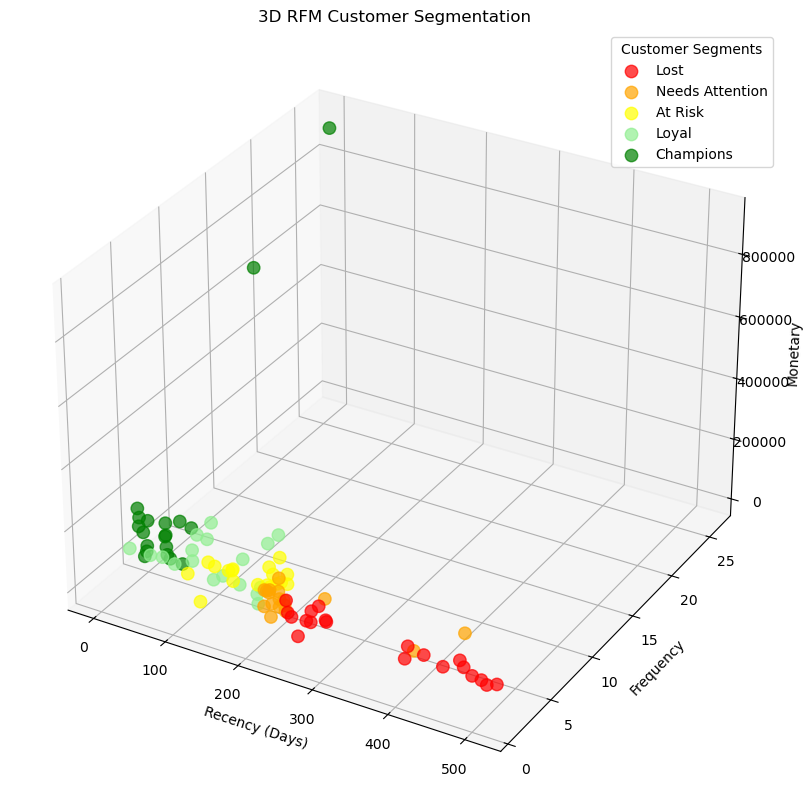

In [31]:
from mpl_toolkits.mplot3d import Axes3D # Import 3D plotting toolkit for creating 3D scatter plots


fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Data
recency = RFM_segment['RECENCY'].dt.days # Convert recency from timedelta to number of days for plotting
frequency = RFM_segment['FREQUENCY'] # Frequency data for plotting
monetary = RFM_segment['MONETARY'] # Monetary data for plotting

# Colors for segments
segment_colors = {  # Define colors for each customer segment to enhance visualization
    'Lost': 'red',
    'Needs Attention': 'orange',
    'At Risk': 'yellow',
    'Loyal': 'lightgreen',
    'Champions': 'green'
}

# Plot each segment separately
for segment, color in segment_colors.items(): # Loop through each segment and plot them with different colors for better distinction
    
    segment_data = RFM_segment[
        RFM_segment['Segment_name'] == segment
    ]
    
    ax.scatter(
        segment_data['RECENCY'].dt.days,
        segment_data['FREQUENCY'],
        segment_data['MONETARY'],
        
        color=color,
        label=segment,
        
        s=80, # Set marker size for better visibility
        alpha=0.7 # Set marker transparency for better visualization of overlapping points
    )

# Labels
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

# Title
ax.set_title('3D RFM Customer Segmentation')

# Legend
ax.legend(title='Customer Segments')

plt.show()

#### *Customer Segment Size*

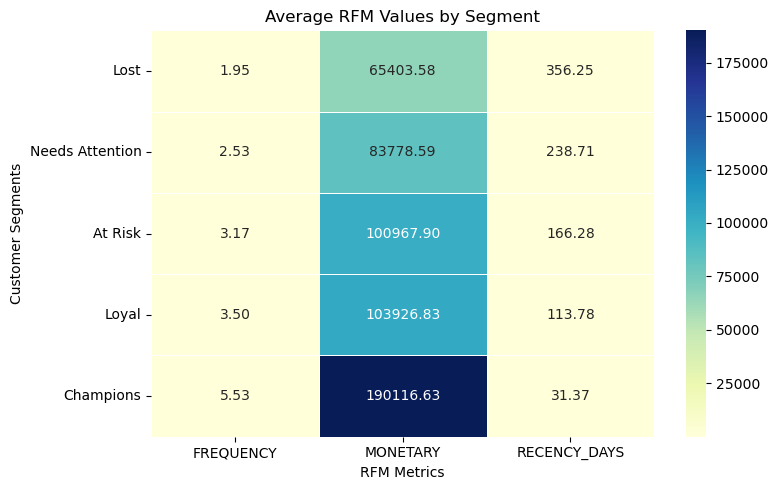

In [32]:
plt.figure(figsize=(8,5)) # Set figure size for better visibility
RFM_segment['RECENCY_DAYS'] = RFM_segment['RECENCY'].dt.days # Convert recency from timedelta to number of days for plotting
RFM_pivot = RFM_segment.pivot_table(
    index='Segment_name',
    values=['RECENCY_DAYS', 'FREQUENCY', 'MONETARY'],
    aggfunc='mean',
    observed=True
)

sns.heatmap( # Create a heatmap to visualize average RFM values for each customer segment
    RFM_pivot,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Average RFM Values by Segment')
plt.xlabel('RFM Metrics')
plt.ylabel('Customer Segments')

plt.tight_layout()
plt.show()

#### *Customer Segment Size*

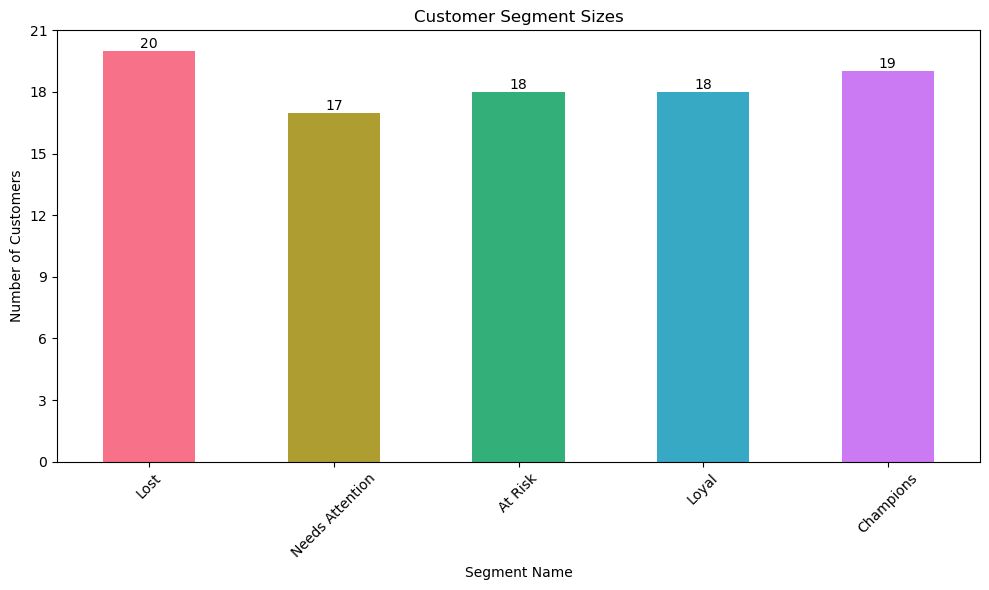

In [34]:
from matplotlib.ticker import MaxNLocator # Import MaxNLocator to set y-axis ticks to integers


RFM_segment_size =RFM_segment.groupby('Segment_name',observed = True).size()
ax = RFM_segment_size.plot(kind='bar', figsize=(10,6), color= sns.color_palette("husl", len(RFM_segment_size))) # Plot segment size as a bar chart
for x in ax.patches: # Loop through each bar in the plot
    ax.annotate( # Annotate each bar with its height (segment size)
        str(x.get_height()),  # Get the height of the bar and convert it to string for annotation
        (x.get_x() + x.get_width() / 2, x.get_height()),  # Position the annotation at the center top of the bar
        ha='center', va='bottom'
    ) # Annotate bars with segment size values
ax.set_title('Customer Segment Sizes') # Title for the plot
ax.set_xlabel('Segment Name') # X-axis label
ax.set_ylabel('Number of Customers') # Y-axis label
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticklabels(RFM_segment_size.index, rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent clipping of labels
plt.show()


#### *Recency vs Monetary Value by Customer Segment(Scatter Plot)*

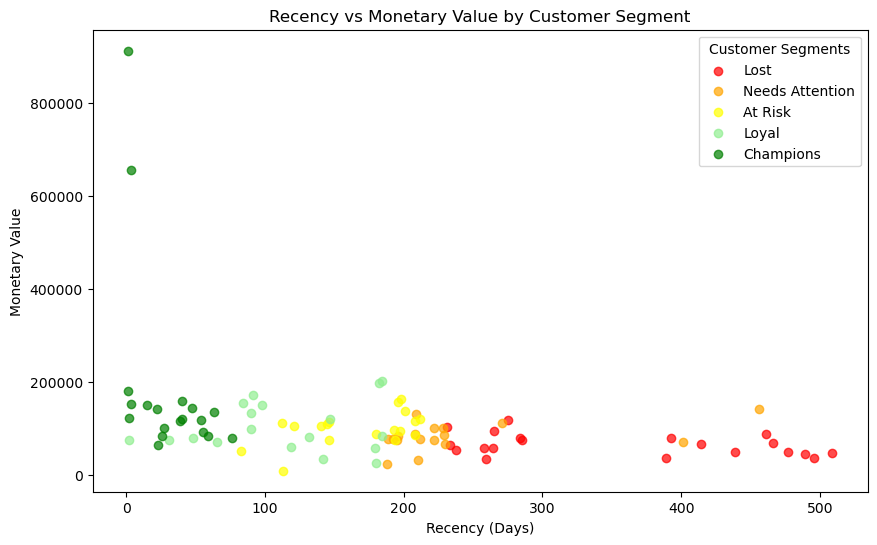

In [33]:
plt.figure(figsize=(10,6))

segment_colors = {
    'Lost': 'red',
    'Needs Attention': 'orange',
    'At Risk': 'yellow',
    'Loyal': 'lightgreen',
    'Champions': 'green'
}

for segment, color in segment_colors.items(): # Loop through each segment and plot them with different colors for better distinction
     
    segment_data = RFM_segment[ # Filter data for the current segment to plot them separately
        RFM_segment['Segment_name'] == segment
    ]
    
    plt.scatter(
        segment_data['RECENCY_DAYS'],
        segment_data['MONETARY'],
        
        color=color,
        label=segment,
        
        alpha=0.7
    )

plt.title('Recency vs Monetary Value by Customer Segment')

plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')

plt.legend(title='Customer Segments')

plt.show()

---

#### Author : *Huseyn Ahmadov*

---

# <p align =center> *Thanks for you Considerations!*